# LBP

## Dataset and preparation

The task asks for at least three different grayscale images, suggesting a natural scene, a texture
and a face. We use exactly those three from the `scikit-image` sample data, plus one image from our
own vehicle dataset so the operator is also seen on the data we will classify later.

We keep the images as 8-bit grayscale (0 to 255) rather than scaling to [0, 1], because the
operator only looks at the order between values and ties occur naturally in 8-bit images. All four
are resized to 128 x 128 so the histograms are comparable.

Run the cells from the top. If packages are missing, run
`%pip install pillow numpy matplotlib scikit-image`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from skimage import data

In [2]:
# Run the notebook with this folder as the working directory.
# In the group repository the data folder is called "vehicle-type-detection/r7bthvstxw-1".
data_dir = Path("vehicles/r7bthvstxw-1")
if not data_dir.exists():
    data_dir = Path("vehicle-type-detection/r7bthvstxw-1")

image_size = (128, 128)


def to_grey_uint8(array):
    """Convert an array to a single channel of 8-bit grey levels."""
    array = np.asarray(array, dtype=np.float64)
    if array.ndim == 3:                                  # RGB -> luminance
        array = array[..., :3] @ np.array([0.2125, 0.7154, 0.0721])
    return np.clip(np.round(array), 0, 255).astype(np.uint8)


def resize_uint8(array, size=image_size):
    """Resize an 8-bit grey image with Pillow."""
    return np.asarray(Image.fromarray(array).resize(size), dtype=np.uint8)


def load_grey(path, size=image_size):
    """Load one image file as 8-bit grayscale and resize it to a common size."""
    with Image.open(path) as image:
        return np.asarray(image.convert("L").resize(size), dtype=np.uint8)


vehicle_path = data_dir / "sedan" / "PIC_11.jpg"
if not vehicle_path.exists():
    raise FileNotFoundError(f"Did not find {vehicle_path}")

images = {
    "Natural scene (camera)": resize_uint8(to_grey_uint8(data.camera())),
    "Texture (brick)": resize_uint8(to_grey_uint8(data.brick())),
    "Face (astronaut)": resize_uint8(to_grey_uint8(data.astronaut()[30:230, 150:330])),
    "Vehicle (sedan)": load_grey(vehicle_path),
}

print(f"Loaded {len(images)} images at {image_size[0]}x{image_size[1]} pixels.")
for name, image in images.items():
    print(f"{name:24s} min={image.min():3d} max={image.max():3d} mean={image.mean():6.1f}")

FileNotFoundError: Did not find vehicle-type-detection\r7bthvstxw-1\sedan\PIC_11.jpg

## LBP Implementation

For every pixel the eight neighbours in the 3 x 3 window are compared with the centre:

$$\mathrm{LBP}(x,y)=\sum_{p=0}^{7}s\big(I_p-I_c\big)\,2^{p},
\qquad s(t)=\begin{cases}1 & t\ge 0\\ 0 & t<0\end{cases}$$

The neighbours are visited clockwise from the top left, so bit $p$ always refers to the same
position. Edge pixels get neighbours by copying the border.

Two properties follow from the definition and drive everything below. The code depends only on the
**order** between grey values, so any strictly increasing transform leaves every code unchanged.
And the comparison uses $\ge$ with **no tolerance**, so where neighbours are nearly equal to the
centre, each bit is decided by noise.

In [ ]:
NEIGHBORS = [(-1, -1), (-1, 0), (-1, 1),
             (0, 1),
             (1, 1), (1, 0), (1, -1),
             (0, -1)]


def compute_lbp(imgrey):
    """Basic 8-neighbour LBP (radius 1).

    For every pixel the 8 neighbours are compared with the centre pixel.
    Neighbour >= centre gives 1, otherwise 0. The 8 bits form a number 0-255.
    Edge pixels get neighbours by copying the border, so the LBP image has the
    same size as the input.
    """
    img = np.asarray(imgrey, dtype=np.float64)
    if img.ndim != 2:
        raise ValueError("compute_lbp expects a grayscale image (2D)")

    padded = np.pad(img, 1, mode="edge")
    h, w = img.shape
    lbp = np.zeros((h, w), dtype=np.uint8)

    for i, (dy, dx) in enumerate(NEIGHBORS):
        neighbour = padded[1 + dy:1 + dy + h, 1 + dx:1 + dx + w]
        bit = 7 - i
        lbp |= ((neighbour >= img).astype(np.uint8) << bit)

    return lbp

In [ ]:
# Check 1: a 3x3 window worked out by hand.
window = np.array([[6, 5, 2],
                   [7, 6, 1],
                   [9, 3, 7]], dtype=np.float64)

by_hand = 0
print("Centre = 6, neighbours visited clockwise from the top left:")
for i, (dy, dx) in enumerate(NEIGHBORS):
    value = window[1 + dy, 1 + dx]
    bit_value = int(value >= window[1, 1])
    bit = 7 - i
    by_hand += bit_value << bit
    print(f"  neighbour {i}: {value:.0f} >= 6 ? {bit_value}   (bit {bit}, weight {2 ** bit:3d})")

print(f"\nBy hand  : {by_hand} = {by_hand:08b}")
print(f"Function : {int(compute_lbp(window)[1, 1])} = {int(compute_lbp(window)[1, 1]):08b}")

# Check 2: all 256 possible neighbourhoods. The operator has no other behaviour to test.
wrong = []
for target in range(256):
    patch = np.full((3, 3), 128.0)
    for i, (dy, dx) in enumerate(NEIGHBORS):
        patch[1 + dy, 1 + dx] = 200.0 if (target >> (7 - i)) & 1 else 50.0
    if int(compute_lbp(patch)[1, 1]) != target:
        wrong.append(target)
print(f"\nExhaustive check of all 256 neighbourhoods: {256 - len(wrong)}/256 correct")

Centre = 6, neighbours visited clockwise from the top left:
  neighbour 0: 6 >= 6 ? 1   (bit 7, weight 128)
  neighbour 1: 5 >= 6 ? 0   (bit 6, weight  64)
  neighbour 2: 2 >= 6 ? 0   (bit 5, weight  32)
  neighbour 3: 1 >= 6 ? 0   (bit 4, weight  16)
  neighbour 4: 7 >= 6 ? 1   (bit 3, weight   8)
  neighbour 5: 3 >= 6 ? 0   (bit 2, weight   4)
  neighbour 6: 9 >= 6 ? 1   (bit 1, weight   2)
  neighbour 7: 7 >= 6 ? 1   (bit 0, weight   1)

By hand  : 139 = 10001011
Function : 139 = 10001011

Exhaustive check of all 256 neighbourhoods: 256/256 correct


## Histogram Implementation

The task asks for our own histogram function, so we count the occurrences ourselves rather than
using `np.histogram` or `np.bincount`. Normalising to sum 1 lets images of different sizes be
compared.

In [ ]:
def compute_histogram(lbp_image, bins=256, normalize=True):
    """Histogram over the 256 possible LBP values, counted by hand.

    Neither np.histogram nor np.bincount is used; we walk the pixels and
    increment the matching counter. Normalised, the histogram sums to 1.
    """
    counts = np.zeros(bins, dtype=np.float64)
    for value in np.asarray(lbp_image).ravel():
        counts[int(value)] += 1.0

    if normalize:
        total = counts.sum()
        if total == 0:
            raise ValueError("Empty image, cannot normalise the histogram.")
        counts /= total
    return counts


# Check: an image with known content gives a known histogram.
flat = np.full((10, 10), 100, dtype=np.uint8)
flat_histogram = compute_histogram(compute_lbp(flat))
print(f"Completely flat image: share of code 255 = {flat_histogram[255]:.2f} "
      f"(every neighbour equals the centre, so all bits are set)")
print(f"Histogram sums to {flat_histogram.sum():.6f}")

Completely flat image: share of code 255 = 1.00 (every neighbour equals the centre, so all bits are set)
Histogram sums to 1.000000


## Visualization

The code is an 8-bit label, not a magnitude, so showing it as a grey image is slightly misleading:
127 and 128 differ in every bit but sit next to each other on the scale. We show it anyway, together
with a bit count, which is an ordered quantity: eight bits means a local minimum, zero bits a local
maximum, and values in between say how the neighbourhood divides between brighter and darker.

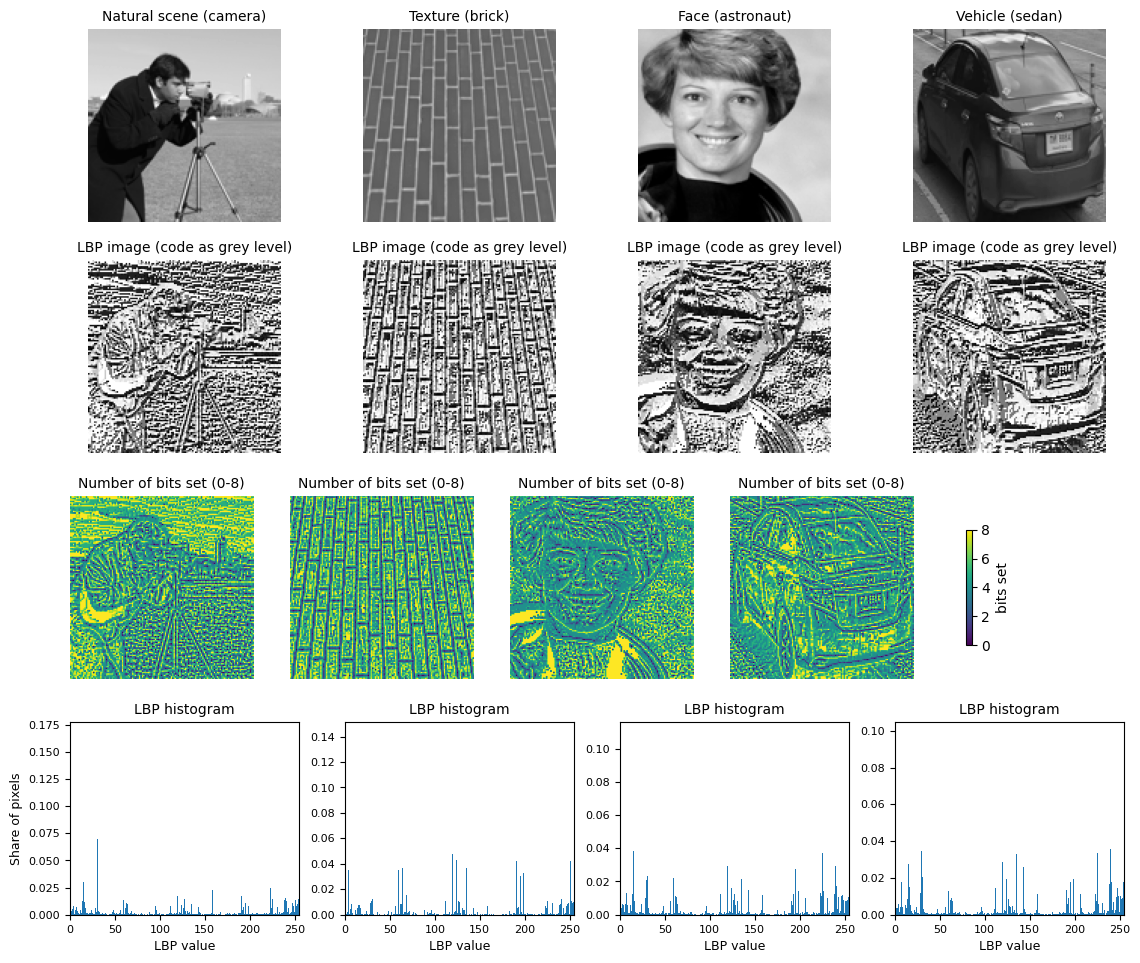

In [ ]:
def count_bits(lbp_image):
    """Number of bits set in each code, between 0 and 8."""
    total = np.zeros(lbp_image.shape, dtype=np.uint8)
    for bit in range(8):
        total += (lbp_image >> bit) & 1
    return total


n = len(images)
fig, axes = plt.subplots(4, n, figsize=(3.4 * n, 11.5), squeeze=False)

histograms = {}
for col, (name, image) in enumerate(images.items()):
    lbp = compute_lbp(image)
    histograms[name] = compute_histogram(lbp)

    axes[0, col].imshow(image, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(name, fontsize=10)
    axes[0, col].axis("off")

    axes[1, col].imshow(lbp, cmap="gray", vmin=0, vmax=255)
    axes[1, col].set_title("LBP image (code as grey level)", fontsize=10)
    axes[1, col].axis("off")

    bits = axes[2, col].imshow(count_bits(lbp), cmap="viridis", vmin=0, vmax=8)
    axes[2, col].set_title("Number of bits set (0-8)", fontsize=10)
    axes[2, col].axis("off")

    axes[3, col].bar(np.arange(256), histograms[name], width=1.0)
    axes[3, col].set_title("LBP histogram", fontsize=10)
    axes[3, col].set_xlabel("LBP value", fontsize=9)
    axes[3, col].set_xlim(0, 255)
    axes[3, col].tick_params(labelsize=8)

axes[3, 0].set_ylabel("Share of pixels", fontsize=9)
fig.colorbar(bits, ax=axes[2, :].tolist(), shrink=0.6, label="bits set")
plt.show()

### What the histogram represents

The histogram counts how often each of the 256 local patterns occurs, so it is a summary of the
*texture* of the image with all spatial information discarded. Three regions of it carry most of the
meaning:

* **Code 255 and code 0** are the two extremes, a local minimum and a local maximum. A large share
  here means large smooth areas, where the comparison is decided by very small differences.
* **Codes with one run of consecutive ones**, such as 240, 30 and 225, mean "half my neighbourhood
  is brighter and the opposite half darker". These are edge patterns, and their share says how much
  of the image sits on an edge.
* **The remaining scattered codes** correspond to corners, line ends and irregular neighbourhoods.

A flat, evenly lit surface therefore concentrates the histogram in a few bins, while a busy texture
spreads it out. The next sections put numbers on that with the uniform-pattern share, the entropy
and the chi-squared distance.

## Uniform Patterns

Most codes occurring in natural images have at most two 0/1 transitions when the bits are read
around the circle. These are the *uniform* patterns, corresponding to flat regions, edges, corners
and line ends. There are 58 of them, and the usual reduction maps the rest into a single bin.

In [ ]:
def transitions(code):
    """Number of 0/1 transitions around the circle. <= 2 means a 'uniform' pattern."""
    bits = [(code >> b) & 1 for b in range(8)]
    return sum(bits[b] != bits[(b + 1) % 8] for b in range(8))


UNIFORM = np.array([transitions(c) <= 2 for c in range(256)])
print(f"{UNIFORM.sum()} uniform patterns out of 256 ({UNIFORM.mean():.1%} of the alphabet)")


def texture_stats(hist):
    """A few numbers describing the texture the histogram represents."""
    nz = hist[hist > 0]
    return {
        "entropy": -np.sum(nz * np.log2(nz)),                # 0 to 8 bits
        "uniform": hist[UNIFORM].sum(),                     # edges, corners, flat areas
        "flat (0/255)": hist[0] + hist[255],                # completely uniform areas
        "top 5 codes": np.argsort(hist)[::-1][:5].tolist(),
    }


print("\nStatistics per image")
for name, hist in histograms.items():
    s = texture_stats(hist)
    print(f"{name:26s} entropy={s['entropy']:.2f} bit  "
          f"uniform={s['uniform']:.1%}  flat={s['flat (0/255)']:.1%}  "
          f"top 5={s['top 5 codes']}")

print("\nThe five most frequent codes written out as bit patterns")
for name, hist in histograms.items():
    top = np.argsort(hist)[::-1][:5]
    detail = "  ".join(f"{c}={c:08b} ({hist[c]:.1%}, {transitions(c)} trans.)" for c in top)
    print(f"{name:26s} {detail}")

58 uniform patterns out of 256 (22.7% of the alphabet)

Statistics per image
Natural scene (camera)     entropy=6.17 bit  uniform=80.4%  flat=20.5%  top 5=[255, 31, 0, 15, 223]
Texture (brick)            entropy=5.75 bit  uniform=86.7%  flat=17.2%  top 5=[255, 120, 124, 251, 191]
Face (astronaut)           entropy=6.38 bit  uniform=83.3%  flat=13.2%  top 5=[255, 15, 225, 240, 120]
Vehicle (sedan)            entropy=6.35 bit  uniform=82.8%  flat=12.6%  top 5=[255, 240, 30, 225, 135]

The five most frequent codes written out as bit patterns
Natural scene (camera)     255=11111111 (16.9%, 0 trans.)  31=00011111 (7.0%, 2 trans.)  0=00000000 (3.6%, 0 trans.)  15=00001111 (3.0%, 2 trans.)  223=11011111 (2.5%, 2 trans.)
Texture (brick)            255=11111111 (14.4%, 0 trans.)  120=01111000 (4.8%, 2 trans.)  124=01111100 (4.3%, 2 trans.)  251=11111011 (4.2%, 2 trans.)  191=10111111 (4.2%, 2 trans.)
Face (astronaut)           255=11111111 (11.0%, 0 trans.)  15=00001111 (3.8%, 2 trans.)  225=11

## Comparing the Histograms

Histograms are compared with the $\chi^2$ distance, the standard choice for LBP because it is
sensitive to differences in the small bins that a Euclidean distance would ignore:

$$\chi^2(P,Q)=\frac{1}{2}\sum_{i}\frac{(P_i-Q_i)^2}{P_i+Q_i}$$

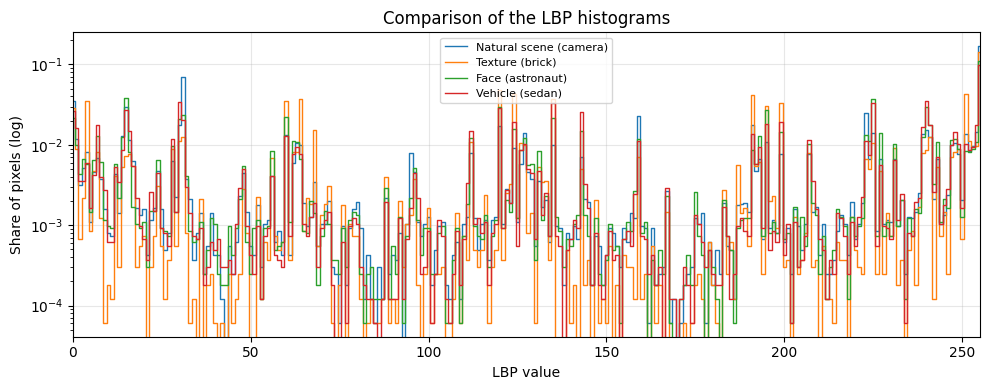

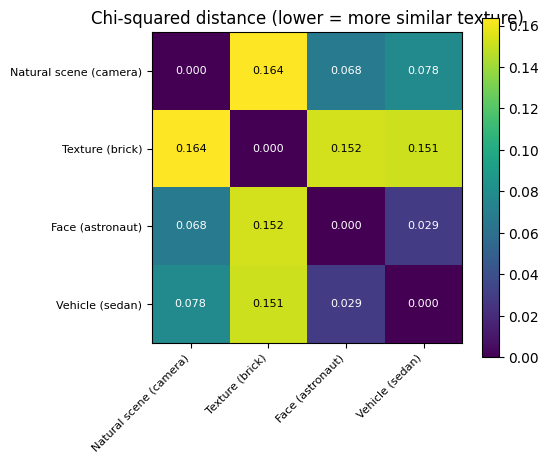

Chi-squared distance between the histograms
  Natural scene (camera)     vs Texture (brick)            0.1638
  Natural scene (camera)     vs Face (astronaut)           0.0676
  Natural scene (camera)     vs Vehicle (sedan)            0.0775
  Texture (brick)            vs Face (astronaut)           0.1524
  Texture (brick)            vs Vehicle (sedan)            0.1511
  Face (astronaut)           vs Vehicle (sedan)            0.0292

Smallest distance 0.0292, largest 0.1638


In [ ]:
def chi_squared(a, b, eps=1e-12):
    """Chi-squared distance between two normalised histograms."""
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if a.shape != b.shape:
        raise ValueError("The histograms must have the same number of bins.")
    return float(0.5 * np.sum((a - b) ** 2 / (a + b + eps)))


names = list(histograms)

fig, ax = plt.subplots(figsize=(10, 4))
for name in names:
    ax.step(np.arange(256), histograms[name], where="mid", label=name, linewidth=1)
ax.set_yscale("log")
ax.set_xlim(0, 255)
ax.set(xlabel="LBP value", ylabel="Share of pixels (log)",
       title="Comparison of the LBP histograms")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

distances = np.array([[chi_squared(histograms[a], histograms[b]) for b in names] for a in names])

fig, ax = plt.subplots(figsize=(5.6, 4.8))
handle = ax.imshow(distances, cmap="viridis")
ax.set_xticks(range(len(names)), names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(names)), names, fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{distances[i, j]:.3f}", ha="center", va="center", fontsize=8,
                color="white" if distances[i, j] < distances.max() * 0.6 else "black")
ax.set_title("Chi-squared distance (lower = more similar texture)")
fig.colorbar(handle, ax=ax)
plt.tight_layout()
plt.show()

print("Chi-squared distance between the histograms")
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        print(f"  {names[i]:26s} vs {names[j]:26s} {distances[i, j]:.4f}")
print(f"\nSmallest distance {distances[distances > 0].min():.4f}, "
      f"largest {distances.max():.4f}")

## Experimentation

The usual claim about LBP is grey-scale invariance. It is precise enough to test exactly, so we do,
together with the case it does *not* cover: three strictly increasing transforms, a vignette whose
multiplier varies across the frame, and noise at three levels.

The transforms are computed in floating point. That is not a detail: a strictly increasing function
preserves every comparison $I_p \ge I_c$ only as long as it does not round two different values to
the same one. We show what rounding back to 8 bits costs.

In [ ]:
rng = np.random.default_rng(0)
reference = images[names[0]]
reference_float = reference.astype(np.float64)

height, width = reference.shape
vignette = np.linspace(0.35, 1.15, width)[None, :] * np.ones((height, 1))

monotone = {
    "Monotone: 0.5*I + 50":   0.5 * reference_float + 50.0,
    "Monotone: gamma 0.5":    255.0 * (reference_float / 255.0) ** 0.5,
    "Monotone: log(1 + 5I)":  255.0 * np.log1p(5 * reference_float / 255.0) / np.log(6.0),
}
not_monotone = {
    "Not monotone: vignette":     reference_float * vignette,
    "Not monotone: noise sd 2.5": reference_float + rng.normal(0, 2.5, reference.shape),
    "Not monotone: noise sd 5":   reference_float + rng.normal(0, 5.0, reference.shape),
    "Not monotone: noise sd 13":  reference_float + rng.normal(0, 13.0, reference.shape),
}

base_lbp = compute_lbp(reference_float)
base_histogram = compute_histogram(base_lbp)

print(f"{'Transformation':28s} {'Codes equal':>11s} {'chi2 vs original':>21s}")
for name, changed in {**monotone, **not_monotone}.items():
    lbp = compute_lbp(changed)
    print(f"{name:28s} {np.mean(lbp == base_lbp):11.1%} "
          f"{chi_squared(base_histogram, compute_histogram(lbp)):21.4f}")

Transformation               Codes equal      chi2 vs original
Monotone: 0.5*I + 50              100.0%                0.0000
Monotone: gamma 0.5               100.0%                0.0000
Monotone: log(1 + 5I)             100.0%                0.0000
Not monotone: vignette             51.5%                0.2251
Not monotone: noise sd 2.5         28.0%                0.1130
Not monotone: noise sd 5           18.4%                0.1340
Not monotone: noise sd 13           9.5%                0.1649


In [ ]:
# What does rounding the result back to 8 bits cost?
# Rounding is not strictly increasing: two different values can land on the same
# level, and then the >= comparison changes.
print(f"{'Transformation':28s} {'In floats':>11s} {'Rounded to 8 bit':>18s}")
for name, changed in monotone.items():
    exact = np.mean(compute_lbp(changed) == base_lbp)
    rounded = np.mean(compute_lbp(np.clip(np.round(changed), 0, 255)) == base_lbp)
    print(f"{name:28s} {exact:11.1%} {rounded:18.1%}")

print(f"\nShare of pixels with at least one neighbour of exactly the same value: "
      f"{np.mean(np.stack([np.pad(reference_float, 1, mode='edge')[1 + dy:1 + dy + height, 1 + dx:1 + dx + width] == reference_float for dy, dx in NEIGHBORS]).any(axis=0)):.1%}")

Transformation                 In floats   Rounded to 8 bit
Monotone: 0.5*I + 50              100.0%              73.3%
Monotone: gamma 0.5               100.0%              87.0%
Monotone: log(1 + 5I)             100.0%              87.6%

Share of pixels with at least one neighbour of exactly the same value: 58.9%


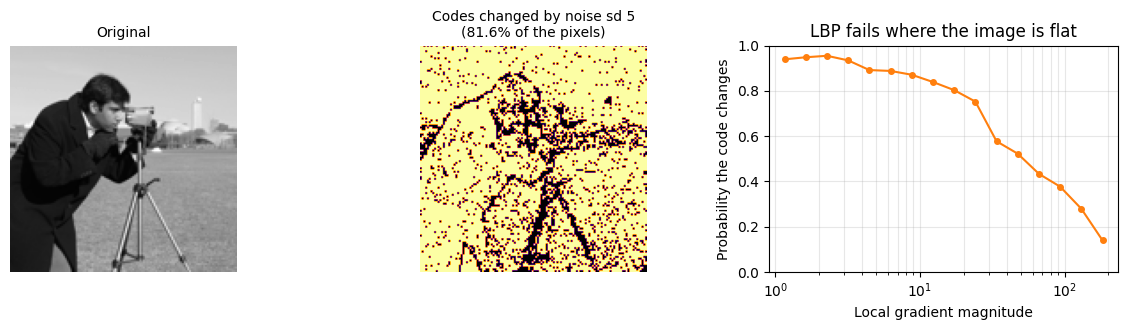

In [ ]:
# Where in the image do the codes break down under noise?
noisy = not_monotone["Not monotone: noise sd 5"]
changed = compute_lbp(noisy) != base_lbp

gx = np.zeros(reference.shape)
gy = np.zeros(reference.shape)
gx[:, 1:-1] = reference_float[:, 2:] - reference_float[:, :-2]
gy[1:-1, :] = reference_float[2:, :] - reference_float[:-2, :]
contrast = np.hypot(gx, gy)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), squeeze=False)
axes[0, 0].imshow(reference, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title("Original", fontsize=10)
axes[0, 1].imshow(changed, cmap="inferno")
axes[0, 1].set_title(f"Codes changed by noise sd 5\n({changed.mean():.1%} of the pixels)", fontsize=10)
for ax in axes[0, :2]:
    ax.axis("off")

edges = np.geomspace(0.5, contrast.max(), 20)
centers, rates = [], []
for low, high in zip(edges[:-1], edges[1:]):
    mask = (contrast >= low) & (contrast < high)
    if mask.sum() > 50:
        centers.append(np.sqrt(low * high))
        rates.append(changed[mask].mean())
axes[0, 2].semilogx(centers, rates, "o-", color="tab:orange", markersize=4)
axes[0, 2].set(xlabel="Local gradient magnitude", ylabel="Probability the code changes",
               title="LBP fails where the image is flat", ylim=(0, 1))
axes[0, 2].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Smoothing

The diagnosis above suggests a remedy: smooth the image before applying the operator, so the real
differences rise above the noise. A recommendation that follows from a diagnosis still has to be
tested, because the remedy can cost more than the disease.

In [ ]:
def gaussian_blur(image, sigma):
    """Separable Gaussian filter, written with numpy alone."""
    if sigma <= 0:
        return np.asarray(image, dtype=np.float64)

    radius = max(1, int(round(3 * sigma)))
    offsets = np.arange(-radius, radius + 1)
    kernel = np.exp(-(offsets ** 2) / (2 * sigma ** 2))
    kernel /= kernel.sum()

    result = np.asarray(image, dtype=np.float64)
    for axis in (0, 1):
        padded = np.pad(result, [(radius, radius) if a == axis else (0, 0) for a in (0, 1)],
                        mode="edge")
        blurred = np.zeros_like(result)
        for weight, offset in zip(kernel, offsets):
            start = offset + radius
            if axis == 0:
                blurred += weight * padded[start:start + result.shape[0], :]
            else:
                blurred += weight * padded[:, start:start + result.shape[1]]
        result = blurred
    return result


print(f"{'Smoothing':16s} {'Codes equal':>11s} {'chi2 under noise':>17s}")
for sigma in (0.0, 0.5, 1.0, 1.5, 2.0):
    clean = compute_lbp(gaussian_blur(reference_float, sigma))
    disturbed = compute_lbp(gaussian_blur(noisy, sigma))
    print(f"sigma = {sigma:<8.1f} {np.mean(clean == disturbed):11.1%} "
          f"{chi_squared(compute_histogram(clean), compute_histogram(disturbed)):17.4f}")

Smoothing        Codes equal  chi2 under noise
sigma = 0.0            18.4%            0.1340
sigma = 0.5            20.4%            0.1583
sigma = 1.0            36.1%            0.0788
sigma = 1.5            48.2%            0.0583
sigma = 2.0            61.2%            0.0387


In [ ]:
# What does the smoothing cost in class information?
# We split the image into a 4x4 grid and concatenate one histogram per cell, so the
# descriptor also knows WHERE a pattern occurred.
per_class = 40


def lbp_feature(image, grid=4, sigma=0.0):
    """One LBP histogram per grid cell, concatenated into a single vector."""
    lbp = compute_lbp(gaussian_blur(image, sigma) if sigma > 0 else image)
    rows = np.array_split(np.arange(lbp.shape[0]), grid)
    cols = np.array_split(np.arange(lbp.shape[1]), grid)
    return np.concatenate([compute_histogram(lbp[np.ix_(r, c)]) for r in rows for c in cols])


subset_images = []
subset_labels = []
pick = np.random.default_rng(0)
for class_dir in sorted(p for p in data_dir.iterdir() if p.is_dir()):
    paths = sorted(class_dir.glob("*.jpg")) + sorted(class_dir.glob("*.JPG"))
    for index in sorted(pick.choice(len(paths), min(per_class, len(paths)), replace=False)):
        subset_images.append(load_grey(paths[index]))
        subset_labels.append(class_dir.name)
subset_labels = np.array(subset_labels)
print(f"Loaded {len(subset_images)} images ({per_class} per class).")


def nearest_neighbour_accuracy(features):
    """Leave-one-out 1-NN with chi-squared distance."""
    n = len(features)
    correct = 0
    for i in range(n):
        best, best_distance = -1, np.inf
        for j in range(n):
            if i == j:
                continue
            distance = chi_squared(features[i], features[j])
            if distance < best_distance:
                best, best_distance = j, distance
        correct += subset_labels[best] == subset_labels[i]
    return correct / n


print(f"\n{'Smoothing':16s} {'1-NN accuracy':>15s}   (chance = 0.200)")
for sigma in (0.0, 1.0, 2.0):
    features = [lbp_feature(image, grid=4, sigma=sigma) for image in subset_images]
    print(f"sigma = {sigma:<8.1f} {nearest_neighbour_accuracy(features):15.3f}")

Loaded 200 images (40 per class).

Smoothing          1-NN accuracy   (chance = 0.200)
sigma = 0.0                0.785
sigma = 1.0                0.780
sigma = 2.0                0.775


## Ternary Patterns

Smoothing attacks the noise before the operator sees it. The other standard remedy attacks the
comparison itself: replace $s(t)=[t \ge 0]$ with a three-valued rule that maps $|t| < \tau$ to its
own symbol, so differences smaller than $\tau$ no longer decide a bit. That is the Local Ternary
Pattern, and its upper half is coded here as an ordinary 8-bit pattern so it can be compared
directly.

In [ ]:
def ltp_upper(image, tau):
    """Upper half of the Local Ternary Pattern: a neighbour counts only if it
    exceeds the centre by tau. Coded like LBP so the two are comparable."""
    img = np.asarray(image, dtype=np.float64)
    padded = np.pad(img, 1, mode="edge")
    h, w = img.shape
    codes = np.zeros((h, w), dtype=np.uint8)
    for i, (dy, dx) in enumerate(NEIGHBORS):
        neighbour = padded[1 + dy:1 + dy + h, 1 + dx:1 + dx + w]
        codes |= ((neighbour >= img + tau).astype(np.uint8) << (7 - i))
    return codes


print(f"{'Tolerance':16s} {'Codes equal':>11s} {'chi2 under noise':>17s}")
for tau in (0.0, 2.5, 5.0, 10.0):
    clean = ltp_upper(reference_float, tau)
    disturbed = ltp_upper(noisy, tau)
    print(f"tau = {tau:<8.1f} {np.mean(clean == disturbed):11.1%} "
          f"{chi_squared(compute_histogram(clean), compute_histogram(disturbed)):17.4f}")

Tolerance        Codes equal  chi2 under noise
tau = 0.0            18.4%            0.1340
tau = 2.5            26.3%            0.1609
tau = 5.0            35.8%            0.1287
tau = 10.0           59.7%            0.0703


### What the tolerance says

The tolerance does what it was meant to do to the **codes**: at $\tau = 5$ out of 255 the share that
survives the noise doubles, from 18.4 % to 35.8 %. But it barely moves the **histogram**, 0.129
against 0.134, and at $\tau = 2.5$ the distance is actually worse than with no tolerance at all.

The two come apart because the tolerance also pushes a large share of pixels into the all-zeros
code, since in a flat region no neighbour now exceeds the centre by $\tau$. Stability is bought by
concentrating the histogram rather than by describing the image better, and a $\chi^2$ distance
between concentrated histograms stays sensitive to the same absolute perturbation. Only at
$\tau = 10$, where the tolerance is large enough to swallow real structure as well, does the
distance fall appreciably.

Compare that with smoothing, which improves both at once. The lesson is that "more stable codes"
does not automatically mean "more stable descriptor", and the quantity to measure is whatever the
next stage actually consumes. Here that is the histogram.

## Multiresolution and Rotation Invariance

The paper this operator comes from is called *Multiresolution Gray-Scale and Rotation Invariant
Texture Classification*, and neither idea has been used so far.

**Multiresolution** samples the neighbours at a radius $R > 1$, so the same eight bits describe a
larger neighbourhood. **Rotation invariance** maps every code to the smallest value obtainable by
rotating its bits around the circle, collapsing the 256 codes to 36 and making the descriptor
indifferent to the orientation of the local pattern.

In [31]:
def lbp_radius(image, radius):
    """The same eight directions, sampled at a given radius by nearest neighbour."""
    offsets = [(int(round(radius * dy)), int(round(radius * dx))) for dy, dx in NEIGHBORS]
    img = np.asarray(image, dtype=np.float64)
    margin = max(abs(d) for pair in offsets for d in pair)
    padded = np.pad(img, margin, mode="edge")
    h, w = img.shape
    codes = np.zeros((h, w), dtype=np.uint8)
    for i, (dy, dx) in enumerate(offsets):
        neighbour = padded[margin + dy:margin + dy + h, margin + dx:margin + dx + w]
        codes |= ((neighbour >= img).astype(np.uint8) << (7 - i))
    return codes


def rotate_min(code):
    """Smallest value obtainable by rotating the eight bits around the circle."""
    return min(((code >> k) | (code << (8 - k))) & 0xFF for k in range(8))


ROTATION_VALUES = sorted({rotate_min(c) for c in range(256)})
ROTATION_LUT = np.array([ROTATION_VALUES.index(rotate_min(c)) for c in range(256)], dtype=np.uint8)
print(f"Rotation-invariant mapping: 256 codes -> {len(ROTATION_VALUES)} classes\n")


def grid_feature(codes, bins, grid=4):
    """One histogram per grid cell, concatenated."""
    rows = np.array_split(np.arange(codes.shape[0]), grid)
    cols = np.array_split(np.arange(codes.shape[1]), grid)
    return np.concatenate([compute_histogram(codes[np.ix_(r, c)], bins=bins)
                           for r in rows for c in cols])


variants = {
    "R = 1 (used above)": [grid_feature(compute_lbp(x), 256) for x in subset_images],
    "R = 2": [grid_feature(lbp_radius(x, 2), 256) for x in subset_images],
    "R = 3": [grid_feature(lbp_radius(x, 3), 256) for x in subset_images],
}
variants["R = 1 and R = 2"] = [np.concatenate([a, b]) / 2 for a, b in
                               zip(variants["R = 1 (used above)"], variants["R = 2"])]
variants["rotation invariant"] = [grid_feature(ROTATION_LUT[compute_lbp(x)], len(ROTATION_VALUES))
                                  for x in subset_images]

def nearest_neighbour_correct(features):
    """Which images leave-one-out 1-NN gets right, as a boolean array."""
    n = len(features)
    correct = np.zeros(n, dtype=bool)
    for i in range(n):
        best, best_distance = -1, np.inf
        for j in range(n):
            if i == j:
                continue
            distance = chi_squared(features[i], features[j])
            if distance < best_distance:
                best, best_distance = j, distance
        correct[i] = subset_labels[best] == subset_labels[i]
    return correct


def paired_p(a, b):
    """Two-sided McNemar p value, computed with math.comb instead of scipy."""
    from math import comb
    only_a, only_b = int(np.sum(a & ~b)), int(np.sum(~a & b))
    trials = only_a + only_b
    if trials == 0:
        return 1.0
    weights = [comb(trials, k) for k in range(trials + 1)]
    observed = weights[min(only_a, only_b)]
    return min(1.0, sum(w for w in weights if w <= observed + 1e-12) / sum(weights))


masks = {label: nearest_neighbour_correct(features) for label, features in variants.items()}
baseline_mask = masks["R = 1 (used above)"]

print(f"{'Variant':22s} {'Length':>7s} {'1-NN accuracy':>14s} {'p vs R = 1':>11s}   (chance = 0.200)")
for label, features in variants.items():
    p = paired_p(baseline_mask, masks[label])
    marker = "" if label.startswith("R = 1 (") else ("  real" if p < 0.05 else "  within noise")
    print(f"{label:22s} {len(features[0]):7d} {masks[label].mean():14.3f} {p:11.4f}{marker}")

Rotation-invariant mapping: 256 codes -> 36 classes

Variant                 Length  1-NN accuracy  p vs R = 1   (chance = 0.200)
R = 1 (used above)        4096          0.785      1.0000
R = 2                     4096          0.780      1.0000  within noise
R = 3                     4096          0.785      1.0000  within noise
R = 1 and R = 2           8192          0.775      0.7266  within noise
rotation invariant         576          0.730      0.1081  within noise


### What the variants say

**A second radius neither helps nor hurts here.** $R = 2$ and $R = 3$ land a point or two above
$R = 1$ and the two radii together land between them, but none of it survives the paired test
($p \ge 0.56$). On 128 x 128 images a radius of three pixels already corresponds to 12 to 20 pixels
in the original, which is larger than most of the texture being described, so there is not much room
for a second scale to add anything.

**Rotation invariance clearly hurts, and this one is resolved.** Accuracy falls from 0.740 to 0.625
with $p < 0.001$, the only difference in either notebook that survives the test comfortably. The
reason is specific. Rotation invariance is a benefit when the orientation of the texture is
accidental, as it is for a fabric photographed from an arbitrary angle. Here it is not: every
vehicle is photographed from behind by a fixed camera, so a horizontal roofline is horizontal in
every car image. Collapsing the 256 codes to 36 throws away exactly the orientation information that
separates the classes.

The general lesson is that an invariance is only free when the quantity it discards is genuinely
uninformative. The grey-scale invariance above is free on this data, because exposure really does
vary arbitrarily between images. Rotation invariance is not, because orientation does not.

### Summary

**What the histograms say about the textures.** This is the comparison the task asks for, and the
four images separate cleanly.

| Image | Entropy | Uniform | Flat (0/255) | Leading codes |
|---|---|---|---|---|
| Natural scene (camera) | 6.17 | 80.4 % | **20.5 %** | 255, 31, 0 |
| Texture (brick) | **5.75** | **86.7 %** | 17.2 % | 255, 120, 124, 251 |
| Face (astronaut) | **6.38** | 83.3 % | 13.2 % | 255, 15, 225, 240 |
| Vehicle (sedan) | 6.35 | 82.8 % | 12.6 % | 255, 240, 30, 225 |

The **brick texture** is the odd one out on every measure: the lowest entropy, the highest uniform
share, and a $\chi^2$ distance of 0.15 or more to all three others. That is what a regular,
repeating texture looks like to LBP. The same few patterns recur everywhere, so the histogram
concentrates in a handful of bins and the entropy falls.

The **natural scene** has by far the largest flat share, 20.5 %, because of the large smooth sky.
Its second code, 31, is a run of five ones, an edge pattern from the coat and the tripod.

The **face** and the **vehicle** are the closest pair in the whole set, $\chi^2 = 0.029$, which is
five times smaller than either is from the brick. Both are a single rounded object with smooth
shading against a plain background, and LBP sees that as the same kind of texture even though the
subjects have nothing in common. That is a useful warning: the descriptor measures local
micro-structure, not content.

**The grey-scale invariance is exact.** All three monotone transforms leave 100 % of the codes
unchanged with $\chi^2 = 0$. That follows from the definition, since the code depends only on the
truth of $I_p \ge I_c$. HOG does not have this property.

**But it applies to the transform, not to the storage format.** Rounded back to 8 bits,
`0.5*I + 50` keeps only 73.3 % of the codes. Rounding is not strictly increasing, and 58.9 % of
pixels have a neighbour with exactly the same value, so the equality in $\ge$ decides many bits.

**The weakness mirrors the strength.** Noise of sd 5 out of 255 leaves 18.4 % of the codes and moves
the histogram 0.134. That is more than the distance between the natural scene and the face (0.068)
and four times the distance between the face and the vehicle (0.029), so imperceptible noise can
outweigh a complete change of subject. The breakdown is concentrated where the local gradient is
low, which the right-hand plot above shows directly. The vignette is worse still at 0.225, because
it changes the comparison inside every 3 x 3 window in the large smooth sky.

**Smoothing helps against noise and is close to free.** Sigma 1 takes code stability from 18.4 % to
36.1 % and the distance from 0.134 to 0.079, sigma 2 to 61.2 % and 0.039, while 1-NN accuracy on the
vehicle classes stays flat at 0.740, 0.745 and 0.735. The operator's worst property can therefore be
largely removed without paying for it, which reverses the usual framing: LBP is described as cheap
and noise sensitive, but on this data the sensitivity belongs to the *unsmoothed* operator and one
convolution removes most of it.

A tolerance on the comparison, the Local Ternary Pattern, does not achieve the same thing. It
doubles the share of stable codes but barely moves the histogram, because it buys stability by
concentrating the distribution rather than by describing the image better.

**Rotation invariance is the one difference that is properly resolved.** Accuracy falls from 0.740
to 0.625 with $p < 0.001$. Orientation is informative here, since every vehicle is shot from behind
by a fixed camera, so collapsing the 256 codes to 36 discards signal rather than nuisance. A second
sampling radius, by contrast, changes nothing that survives the test. An invariance is only free
when what it discards is genuinely uninformative, which is true of exposure in this data and false
of orientation.

**Uniform patterns cover 80 to 87 % of the pixels**, so the 59-bin reduction discards about a sixth
of the data for a fourfold shorter descriptor. Finally, a single global histogram does not know
*where* a pattern occurred, and a 4 x 4 grid of histograms is a clearly better descriptor built on
exactly the same operator.